# Energy Sentinel — Anomaly Detection Modeling

This notebook trains and compares anomaly detection models on the engineered feature dataset.
Goals:
- Train Isolation Forest, LOF, and One-Class SVM per appliance
- Compare model results
- Select and save the best model

# 1 - Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from src.config.settings import settings
from src.models.train import train_all_models, save_model, get_appliance_features
from src.models.predictor import AnomalyPredictor
from src.utils.logger import get_logger

logger = get_logger("modeling")

print("Imports successful")

Imports successful


# 2 - Load Feature Dataset

In [3]:
input_path = settings.PROCESSED_DIR / "house_1_features_2013.parquet"

df_features = pd.read_parquet(input_path)

print(f"Loaded: {input_path}")
print(f"Shape: {df_features.shape}")
print(f"Columns: {len(df_features.columns)}")

Loaded: D:\Github\energy-sentinel\data\processed\house_1_features_2013.parquet
Shape: (525600, 60)
Columns: 60


# 3 - Train Models for All Appliances

In [4]:
appliances = ['Aggregate', 'Washing Machine', 'Dishwasher', 'TV', 'Kettle', 'Fridge', 'Microwave']

trained_models = {}

for appliance in appliances:
    model_dict = train_all_models(df_features, appliance, contamination=0.05)
    save_model(model_dict, appliance)
    trained_models[appliance] = model_dict
    print(f"{appliance}: done")

print("\nAll models trained and saved.")

2026-07-14 14:24:10 | INFO     | src.models.train | Training models for: Aggregate
2026-07-14 14:24:10 | INFO     | src.models.train | Aggregate: training Isolation Forest on 525,600 rows...
2026-07-14 14:24:15 | INFO     | src.models.train | Aggregate: training LOF on 10,000 row sample...
2026-07-14 14:24:16 | INFO     | src.models.train | Aggregate: training One-Class SVM on 10,000 row sample...
2026-07-14 14:24:17 | INFO     | src.models.train | Aggregate: all models trained successfully
2026-07-14 14:24:17 | INFO     | src.models.train | Model saved: D:\Github\energy-sentinel\artifacts\aggregate_models.joblib
Aggregate: done
2026-07-14 14:24:17 | INFO     | src.models.train | Training models for: Washing Machine
2026-07-14 14:24:17 | INFO     | src.models.train | Washing Machine: training Isolation Forest on 525,600 rows...
2026-07-14 14:24:22 | INFO     | src.models.train | Washing Machine: training LOF on 10,000 row sample...
2026-07-14 14:24:23 | INFO     | src.models.train | Wa

# 4 - Anomaly Detection Results

In [5]:
# Run predictions for all appliances using Isolation Forest
results = {}

for appliance in appliances:
    predictor = AnomalyPredictor(appliance, model_name="isolation_forest")
    df_result = predictor.predict(df_features)
    results[appliance] = df_result

    total = len(df_result)
    anomalies = (df_result["anomaly_label"] == -1).sum()
    pct = anomalies / total * 100
    print(f"{appliance:20s} → {anomalies:>7,} anomalies ({pct:.2f}%)")

2026-07-14 14:24:57 | INFO     | src.models.predictor | Loaded model bundle for Aggregate (isolation_forest)
2026-07-14 14:25:05 | INFO     | src.models.predictor | Aggregate (isolation_forest): 26,280 anomalies detected out of 525,600 records
Aggregate            →  26,280 anomalies (5.00%)
2026-07-14 14:25:05 | INFO     | src.models.predictor | Loaded model bundle for Washing Machine (isolation_forest)
2026-07-14 14:25:13 | INFO     | src.models.predictor | Washing Machine (isolation_forest): 26,280 anomalies detected out of 525,600 records
Washing Machine      →  26,280 anomalies (5.00%)
2026-07-14 14:25:13 | INFO     | src.models.predictor | Loaded model bundle for Dishwasher (isolation_forest)
2026-07-14 14:25:20 | INFO     | src.models.predictor | Dishwasher (isolation_forest): 26,255 anomalies detected out of 525,600 records
Dishwasher           →  26,255 anomalies (5.00%)
2026-07-14 14:25:20 | INFO     | src.models.predictor | Loaded model bundle for TV (isolation_forest)
2026-

# 5 - Anomaly Visualization (Fridge)

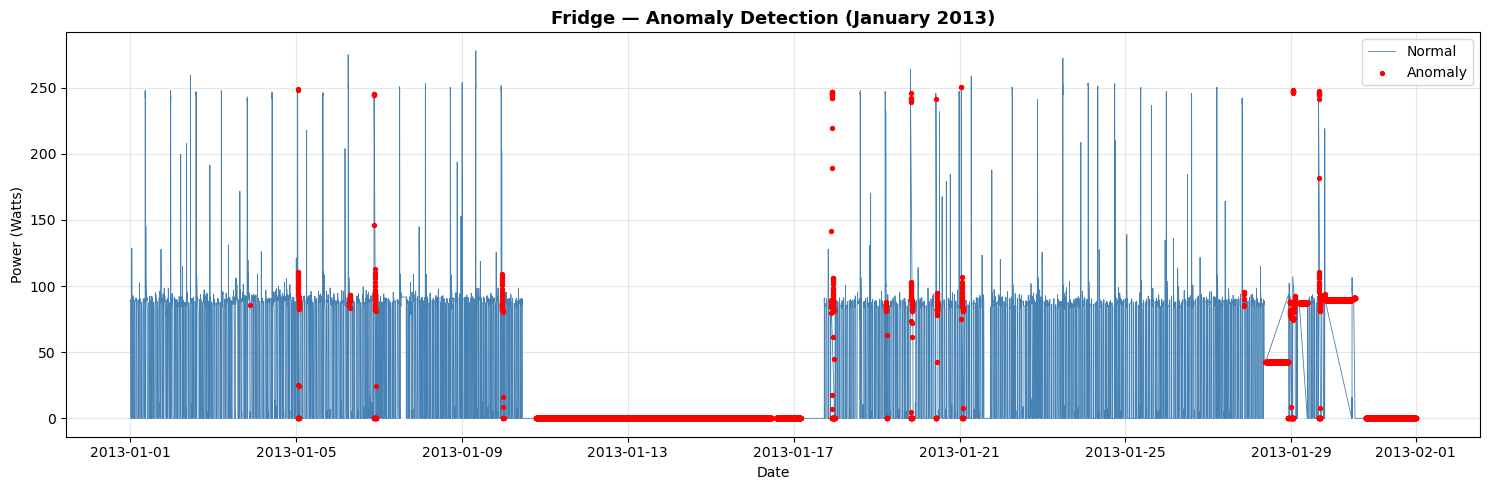

January anomalies: 13,394 out of 44,640 records (30.00%)


In [8]:
fridge_result = results["Fridge"]

# Take the January 2013 slice — for the readable plot
jan = fridge_result["2013-01-01":"2013-01-31"]

normal = jan[jan["anomaly_label"] == 1]
anomaly = jan[jan["anomaly_label"] == -1]

plt.figure(figsize=(15, 5))
plt.plot(normal.index, normal["Fridge"], 
         color="steelblue", linewidth=0.6, label="Normal")
plt.scatter(anomaly.index, anomaly["Fridge"], 
            color="red", s=8, label="Anomaly", zorder=5)
plt.title("Fridge — Anomaly Detection (January 2013)", fontweight="bold", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Power (Watts)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"January anomalies: {len(anomaly):,} out of {len(jan):,} records ({len(anomaly)/len(jan)*100:.2f}%)")

# 6 - Model Comparison (Isolation Forest vs LOF vs One-Class SVM)

In [9]:
# Compare anomaly detection results on 10,000 row sample
sample_idx = np.random.RandomState(42).choice(len(df_features), size=10000, replace=False)
df_sample = df_features.iloc[sample_idx]

appliance = "Fridge"
feature_cols = trained_models[appliance]["feature_cols"]
scaler = trained_models[appliance]["scaler"]

X_sample = df_sample[feature_cols].values
X_scaled = scaler.transform(X_sample)

# Predictions from all 3 models
iso_labels = trained_models[appliance]["isolation_forest"].predict(X_scaled)
lof_labels = trained_models[appliance]["lof"].predict(X_scaled)
ocsvm_labels = trained_models[appliance]["ocsvm"].predict(X_scaled)

# Summary
print("Model Comparison — Fridge (10,000 row sample)\n")
print(f"{'Model':<25} {'Anomalies':>10} {'Anomaly %':>12}")
print("-" * 50)

for name, labels in [
    ("Isolation Forest", iso_labels),
    ("LOF", lof_labels),
    ("One-Class SVM", ocsvm_labels),
]:
    anomalies = (labels == -1).sum()
    pct = anomalies / len(labels) * 100
    print(f"{name:<25} {anomalies:>10,} {pct:>11.2f}%")

Model Comparison — Fridge (10,000 row sample)

Model                      Anomalies    Anomaly %
--------------------------------------------------
Isolation Forest                 436        4.36%
LOF                              515        5.15%
One-Class SVM                    547        5.47%


# 7 - Anomaly Score Distribution

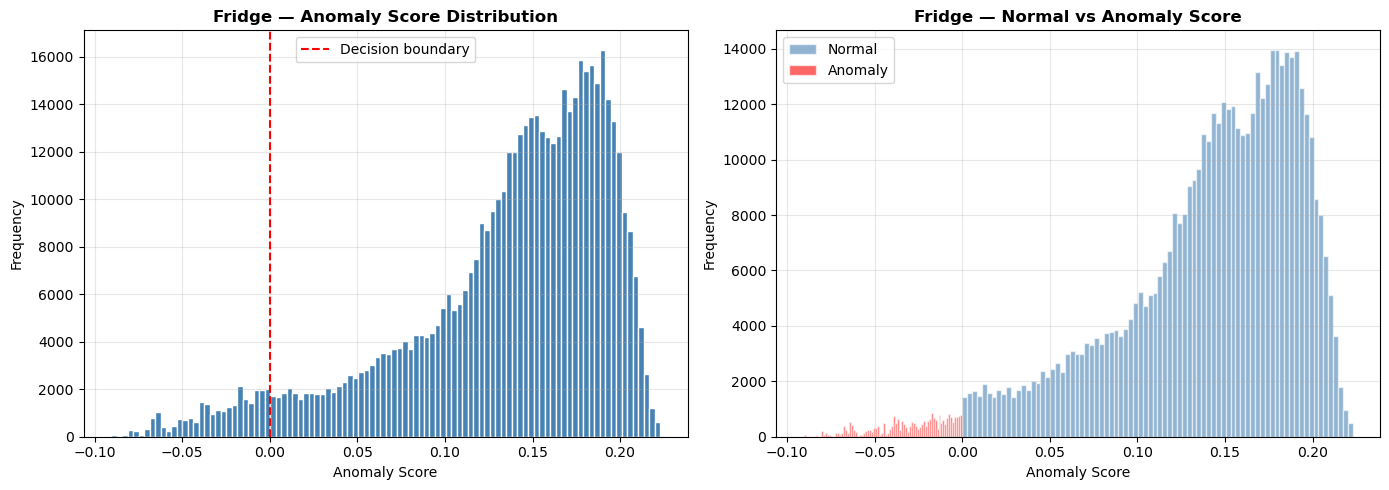

In [10]:
fridge_result = results["Fridge"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Anomaly score distribution
axes[0].hist(fridge_result["anomaly_score"], bins=100, color="steelblue", edgecolor="white")
axes[0].axvline(x=0, color="red", linestyle="--", linewidth=1.5, label="Decision boundary")
axes[0].set_title("Fridge — Anomaly Score Distribution", fontweight="bold")
axes[0].set_xlabel("Anomaly Score")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Normal vs anomaly score
normal_scores = fridge_result[fridge_result["anomaly_label"] == 1]["anomaly_score"]
anomaly_scores = fridge_result[fridge_result["anomaly_label"] == -1]["anomaly_score"]

axes[1].hist(normal_scores, bins=80, alpha=0.6, color="steelblue", label="Normal", edgecolor="white")
axes[1].hist(anomaly_scores, bins=80, alpha=0.6, color="red", label="Anomaly", edgecolor="white")
axes[1].set_title("Fridge — Normal vs Anomaly Score", fontweight="bold")
axes[1].set_xlabel("Anomaly Score")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8 - Modeling Summary

In [11]:
print("=" * 60)
print("MODELING SUMMARY — Energy Sentinel (UK-DALE House 1, 2013)")
print("=" * 60)

print(f"""
TRAINING DATA
-------------
Dataset        : house_1_features_2013.parquet
Total Records  : 525,600
Features       : 60 columns (11 per appliance + 4 time features)
Appliances     : 7

MODELS TRAINED
--------------
Primary Model  : Isolation Forest (trained on full 525,600 rows)
Comparison     : LOF + One-Class SVM (trained on 10,000 row sample)
Contamination  : 0.05 (5% expected anomaly rate)

ANOMALY DETECTION RESULTS (Isolation Forest)
--------------------------------------------""")

for appliance, df_result in results.items():
    total = len(df_result)
    anomalies = (df_result["anomaly_label"] == -1).sum()
    pct = anomalies / total * 100
    print(f"  {appliance:20s} → {anomalies:>6,} anomalies ({pct:.2f}%)")

print(f"""
MODEL SELECTION
---------------
Selected       : Isolation Forest
Reasons        :
  - Trained on full dataset (525,600 rows)
  - Fast training and inference
  - No assumption about data distribution
  - Interpretable via anomaly scores
  - Industry standard for unsupervised anomaly detection

ARTIFACTS SAVED
---------------""")

for appliance in appliances:
    appliance_clean = appliance.replace(" ", "_").lower()
    print(f"  artifacts/{appliance_clean}_models.joblib")

print("\n" + "=" * 60)
print("MODELING COMPLETE — Ready for API and Dashboard")
print("=" * 60)

MODELING SUMMARY — Energy Sentinel (UK-DALE House 1, 2013)

TRAINING DATA
-------------
Dataset        : house_1_features_2013.parquet
Total Records  : 525,600
Features       : 60 columns (11 per appliance + 4 time features)
Appliances     : 7

MODELS TRAINED
--------------
Primary Model  : Isolation Forest (trained on full 525,600 rows)
Comparison     : LOF + One-Class SVM (trained on 10,000 row sample)
Contamination  : 0.05 (5% expected anomaly rate)

ANOMALY DETECTION RESULTS (Isolation Forest)
--------------------------------------------
  Aggregate            → 26,280 anomalies (5.00%)
  Washing Machine      → 26,280 anomalies (5.00%)
  Dishwasher           → 26,255 anomalies (5.00%)
  TV                   → 26,274 anomalies (5.00%)
  Kettle               → 26,246 anomalies (4.99%)
  Fridge               → 26,280 anomalies (5.00%)
  Microwave            → 26,243 anomalies (4.99%)

MODEL SELECTION
---------------
Selected       : Isolation Forest
Reasons        :
  - Trained on ful